In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df = df.dropna(subset=['Context', 'Object', 'Sentiment'])



Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df1 = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df1 = df1.dropna(subset=['Context', 'Object', 'Sentiment'])



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd


file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df1 = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df1 = df1.dropna(subset=['Context', 'Object', 'Sentiment'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## SVM

In [ ]:
# Lọc bỏ các dòng trống
df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

# Mẹo ABSA: Nối Object và Context để SVM biết đang đánh giá cái gì
df['Input_Text'] = df['Object'].astype(str) + " - " + df['Target_Sentence'].astype(str)
X = df['Input_Text']
y = df['Sentiment']

# 2. CHIA TẬP TRAIN / TEST (Tỷ lệ 80/20)
# Dùng stratify=y để đảm bảo tỷ lệ nhãn Positive/Negative/Neutral đều nhau ở cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"📊 Đã chia xong: Train ({len(X_train)} câu) | Test ({len(X_test)} câu)\n")

# 3. TRÍCH XUẤT ĐẶC TRƯNG BẰNG TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. TRAIN MÔ HÌNH SVM
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train_vec, y_train)

# 5. DỰ ĐOÁN VÀ CHẤM ĐIỂM F1
y_pred = svm_model.predict(X_test_vec)

print("="*50)
print("🏆 BẢNG ĐIỂM SVM (BASELINE) TRÊN TẬP TEST")
print("="*50)
print(classification_report(y_test, y_pred))

📊 Đã chia xong: Train (870 câu) | Test (218 câu)

🏆 BẢNG ĐIỂM SVM (BASELINE) TRÊN TẬP TEST
              precision    recall  f1-score   support

    NEGATIVE       0.22      0.12      0.16        16
     NEUTRAL       0.50      0.69      0.58        58
    POSITIVE       0.84      0.76      0.80       144

    accuracy                           0.69       218
   macro avg       0.52      0.52      0.51       218
weighted avg       0.71      0.69      0.69       218



In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. ĐỌC VÀ LÀM SẠCH DATA
file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

# Mẹo ABSA: Nối Object và Context để SVM biết đang đánh giá cái gì
df['Input_Text'] = df['Object'].astype(str) + " - " + df['Target_Sentence'].astype(str)

# ==========================================
# 2. CHIA TẬP TEST CÂN BẰNG (BALANCED TEST)
# ==========================================
# Tìm nhãn có ít mẫu nhất
min_class_count = df['Sentiment'].value_counts().min()
# Lấy 40% của nhãn ít nhất làm số lượng test cho mỗi nhãn
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Bốc đều {n_test_per_class} mẫu cho mỗi nhãn vào tập Test để đảm bảo công bằng...\n")

df_test = df.groupby('Sentiment').sample(n=n_test_per_class, random_state=42)
df_train = df.drop(df_test.index)

X_train = df_train['Input_Text']
y_train = df_train['Sentiment']
X_test = df_test['Input_Text']
y_test = df_test['Sentiment']

# ==========================================
# 3. TRÍCH XUẤT ĐẶC TRƯNG BẰNG TF-IDF
# ==========================================
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ==========================================
# 4. TRAIN MÔ HÌNH SVM
# ==========================================
print("⚙️ Đang huấn luyện mô hình SVM (Support Vector Machine)...")
# Dùng kernel='linear' cực kỳ hiệu quả với dữ liệu Text (TF-IDF)
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train_vec, y_train)

# ==========================================
# 5. DỰ ĐOÁN VÀ CHẤM ĐIỂM F1
# ==========================================
y_pred = svm_model.predict(X_test_vec)

print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM SVM (BASELINE) TRÊN TẬP TEST ĐỀU")
print("="*50)
print(classification_report(y_test, y_pred))

📊 Bốc đều 31 mẫu cho mỗi nhãn vào tập Test để đảm bảo công bằng...

⚙️ Đang huấn luyện mô hình SVM (Support Vector Machine)...

🏆 BẢNG ĐIỂM SVM (BASELINE) TRÊN TẬP TEST ĐỀU
              precision    recall  f1-score   support

    NEGATIVE       0.80      0.13      0.22        31
     NEUTRAL       0.42      0.52      0.46        31
    POSITIVE       0.54      0.87      0.67        31

    accuracy                           0.51        93
   macro avg       0.59      0.51      0.45        93
weighted avg       0.59      0.51      0.45        93



### Mo hinh truyen thn

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

# Ép ngữ cảnh ABSA
df['Input_Text'] = df['Object'].astype(str) + " - " + df['Target_Sentence'].astype(str)

# Chia Train/Test (80-20)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Input_Text'], df['Sentiment'], test_size=0.2, random_state=42, stratify=df['Sentiment']
)

# Trích xuất đặc trưng TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

# Bơm máu SMOTE cho tập Train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)

# 2. KHAI BÁO 3 MÔ HÌNH THÔNG DỤNG NHẤT
models = {
    "📌 LOGISTIC REGRESSION (Hồi quy Logistic)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "🌲 RANDOM FOREST (Rừng ngẫu nhiên)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "📊 NAIVE BAYES (Xác suất thống kê)": MultinomialNB() # Thằng này train siêu nhanh
}

# 3. VÒNG LẶP CHO THI ĐẤU
for name, model in models.items():
    print("\n" + "="*60)
    print(f"⚙️ ĐANG HUẤN LUYỆN: {name}")
    print("="*60)

    # Train mô hình
    model.fit(X_train_smote, y_train_smote)

    # Dự đoán
    y_pred = model.predict(X_test_vec)

    # In bảng điểm
    print(classification_report(y_test, y_pred))


⚙️ ĐANG HUẤN LUYỆN: 📌 LOGISTIC REGRESSION (Hồi quy Logistic)
              precision    recall  f1-score   support

    NEGATIVE       0.10      0.06      0.08        16
     NEUTRAL       0.55      0.53      0.54        58
    POSITIVE       0.80      0.84      0.82       144

    accuracy                           0.70       218
   macro avg       0.48      0.48      0.48       218
weighted avg       0.68      0.70      0.69       218


⚙️ ĐANG HUẤN LUYỆN: 🌲 RANDOM FOREST (Rừng ngẫu nhiên)
              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00        16
     NEUTRAL       0.35      0.16      0.21        58
    POSITIVE       0.68      0.90      0.77       144

    accuracy                           0.63       218
   macro avg       0.34      0.35      0.33       218
weighted avg       0.54      0.63      0.57       218


⚙️ ĐANG HUẤN LUYỆN: 📊 NAIVE BAYES (Xác suất thống kê)
              precision    recall  f1-score   support

    NEGATIV

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# 1. ĐỌC VÀ CHUẨN BỊ DATA
file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

# Ép ngữ cảnh ABSA (Ghép Object và Câu)
df['Input_Text'] = df['Object'].astype(str) + " - " + df['Target_Sentence'].astype(str)

# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU (BALANCED TEST)
# ==========================================
# Tìm nhãn có ít mẫu nhất
min_class_count = df['Sentiment'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Bốc đều {n_test_per_class} mẫu cho mỗi nhãn vào tập Test...")

# Chia tập Test và Train
df_test = df.groupby('Sentiment').sample(n=n_test_per_class, random_state=42)
df_train = df.drop(df_test.index)

X_train_text = df_train['Input_Text']
y_train = df_train['Sentiment']
X_test_text = df_test['Input_Text']
y_test = df_test['Sentiment']

# ==========================================
# 1.3. TRÍCH XUẤT ĐẶC TRƯNG VÀ BƠM MÁU SMOTE
# ==========================================
# Biến chữ thành ma trận số TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

# Dùng SMOTE để nhân bản dữ liệu cho nhãn thiểu số trong tập Train
print("💉 Đang dùng SMOTE bơm thêm dữ liệu ảo cho tập Train...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)

# ==========================================
# 2. KHAI BÁO 3 MÔ HÌNH THÔNG DỤNG NHẤT
# ==========================================
models = {
    "📌 LOGISTIC REGRESSION (Hồi quy Logistic)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "🌲 RANDOM FOREST (Rừng ngẫu nhiên)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "📊 NAIVE BAYES (Xác suất thống kê)": MultinomialNB()
}

# ==========================================
# 3. VÒNG LẶP CHO THI ĐẤU
# ==========================================
for name, model in models.items():
    print("\n" + "="*60)
    print(f"⚙️ ĐANG HUẤN LUYỆN: {name}")
    print("="*60)

    # Train mô hình
    model.fit(X_train_smote, y_train_smote)

    # Dự đoán
    y_pred = model.predict(X_test_vec)

    # In bảng điểm
    print(classification_report(y_test, y_pred))

📊 Bốc đều 31 mẫu cho mỗi nhãn vào tập Test...
💉 Đang dùng SMOTE bơm thêm dữ liệu ảo cho tập Train...

⚙️ ĐANG HUẤN LUYỆN: 📌 LOGISTIC REGRESSION (Hồi quy Logistic)
              precision    recall  f1-score   support

    NEGATIVE       0.67      0.13      0.22        31
     NEUTRAL       0.33      0.32      0.33        31
    POSITIVE       0.49      0.90      0.64        31

    accuracy                           0.45        93
   macro avg       0.50      0.45      0.39        93
weighted avg       0.50      0.45      0.39        93


⚙️ ĐANG HUẤN LUYỆN: 🌲 RANDOM FOREST (Rừng ngẫu nhiên)
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.03      0.06        31
     NEUTRAL       0.33      0.23      0.27        31
    POSITIVE       0.39      0.90      0.55        31

    accuracy                           0.39        93
   macro avg       0.58      0.39      0.29        93
weighted avg       0.58      0.39      0.29        93


⚙️ ĐANG HUẤN LUYỆN:

### Deep learning

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

file_path = '/content/drive/MyDrive/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

df['Input_Text'] = df['Object'].astype(str) + " - " + df['Target_Sentence'].astype(str)

label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df['labels'] = df['Sentiment'].map(label_mapping)

X_train, X_test, y_train, y_test = train_test_split(
    df['Input_Text'].tolist(), df['labels'].tolist(), test_size=0.2, random_state=42, stratify=df['labels']
)

# 2. TIỀN XỬ LÝ TEXT CHO KERAS (Biến chữ thành mảng số)
vocab_size = 5000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding='post')

# Chuyển nhãn sang Numpy Array
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

# Tự động tính trọng số Weighted Loss (Trị dứt điểm lệch nhãn)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_arr), y=y_train_arr)
weight_dict = dict(enumerate(class_weights))

# 3. KIẾN TRÚC MẠNG BI-LSTM
print("🛠️ Đang xây dựng mạng nơ-ron Bi-LSTM...")
model_lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5), # Chống học vẹt (Overfitting)
    Dense(32, activation='relu'),
    Dense(3, activation='softmax') # 3 nhãn phân cực
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. TIẾN HÀNH TRAIN
print("🔥 Bắt đầu Train Bi-LSTM (Chạy 5 Epochs)...")
history = model_lstm.fit(
    X_train_pad, y_train_arr,
    epochs=5,
    batch_size=16,
    validation_data=(X_test_pad, y_test_arr),
    class_weight=weight_dict,
    verbose=1
)

# 5. ĐÁNH GIÁ TRÊN TẬP TEST
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM DEEP LEARNING (BI-LSTM)")
print("="*50)

# Lấy dự đoán có xác suất cao nhất
y_pred_probs = model_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Dịch số sang chữ
reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test_arr]

print(classification_report(y_true_text, y_pred_text))

🛠️ Đang xây dựng mạng nơ-ron Bi-LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd
import numpy as np
import tensorflow as tf

# 🔥 THUỐC GIẢI: Ép TensorFlow xài GPU tiết kiệm, không được tham lam ôm hết RAM
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for dev in physical_devices:
            tf.config.experimental.set_memory_growth(dev, True)
        print("✅ Đã cấu hình GPU thành công cho TensorFlow!")
    except RuntimeError as e:
        print(e)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# 1. ĐỌC VÀ CHUẨN BỊ DATA
file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])
df['Input_Text'] = df['Object'].astype(str) + " - " + df['Target_Sentence'].astype(str)

label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df['labels'] = df['Sentiment'].map(label_mapping)

# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU
# ==========================================
min_class_count = df['labels'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

df_test = df.groupby('labels').sample(n=n_test_per_class, random_state=42)
df_train = df.drop(df_test.index)

X_train, y_train = df_train['Input_Text'].tolist(), df_train['labels'].tolist()
X_test, y_test = df_test['Input_Text'].tolist(), df_test['labels'].tolist()

# ==========================================
# 2. TIỀN XỬ LÝ TEXT CHO KERAS
# ==========================================
vocab_size = 5000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding='post')

y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train_arr), y=y_train_arr)
weight_dict = dict(enumerate(class_weights))

# ==========================================
# 3. KIẾN TRÚC MẠNG BI-LSTM
# ==========================================
print("🛠️ Đang xây dựng mạng nơ-ron Bi-LSTM...")
model_lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# ==========================================
# 4. TIẾN HÀNH TRAIN
# ==========================================
print("🔥 Bắt đầu Train Bi-LSTM (Chạy 5 Epochs)...")
history = model_lstm.fit(
    X_train_pad, y_train_arr,
    epochs=5,
    batch_size=16,
    validation_data=(X_test_pad, y_test_arr),
    class_weight=weight_dict,
    verbose=1
)

# ==========================================
# 5. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM BI-LSTM TRÊN TẬP TEST ĐỀU")
print("="*50)

y_pred_probs = model_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test_arr]

print(classification_report(y_true_text, y_pred_text))

Mounted at /content/drive
🛠️ Đang xây dựng mạng nơ-ron Bi-LSTM...
🔥 Bắt đầu Train Bi-LSTM (Chạy 5 Epochs)...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.4372 - loss: 1.1042 - val_accuracy: 0.3978 - val_loss: 1.0898
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6000 - loss: 1.0130 - val_accuracy: 0.4624 - val_loss: 1.0351
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.7658 - loss: 0.5587 - val_accuracy: 0.4946 - val_loss: 1.1373
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8864 - loss: 0.2240 - val_accuracy: 0.5161 - val_loss: 1.8474
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9447 - loss: 0.1170 - val_accuracy: 0.5269 - val_loss: 1.5942

🏆 BẢNG ĐIỂM BI-LSTM TRÊN TẬP TEST ĐỀU
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step
              precision    recall  f1-score   support

    NEGATIVE       0.91      0.32      0.48        31
     NEUTRAL       0.44      0.45      0.44        31
    POSITIVE       0.50      0.81      0.62        31

    accuracy                           0.53        93
   macro avg       0.62      0

### Bert

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# ==========================================
# 0. CHUẨN BỊ VÀ LÀM SẠCH DATA
# ==========================================
# Đảm bảo nhãn chuẩn chỉ 0, 1, 2
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

# Xóa bỏ dòng trắng để tránh lỗi CUDA
df1 = df1.dropna(subset=['labels'])
df1['labels'] = df1['labels'].astype(int)

# Gộp Object và Sentence để BERT hiểu ngữ cảnh khía cạnh
df1['Input_Text'] = df1['Object'].astype(str) + " [SEP] " + df1['Target_Sentence'].astype(str)

# ==========================================
# 1. CHIA TẬP TEST CÂN BẰNG (BALANCED TEST SET)
# ==========================================
# Bốc đều mỗi nhãn n mẫu để chấm điểm cho công bằng
n_test_per_class = 30
df_test = df1.groupby('labels').sample(n=n_test_per_class, random_state=42)
df_train = df1.drop(df_test.index)

X_train, y_train = df_train['Input_Text'].tolist(), df_train['labels'].tolist()
X_test, y_test = df_test['Input_Text'].tolist(), df_test['labels'].tolist()

# ==========================================
# 2. KHỞI TẠO TOKENIZER & DATASET
# ==========================================
# Dùng bản uncased (không phân biệt hoa thường) cho dữ liệu review Agoda
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH BERT
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args = TrainingArguments(
    output_dir='./results_bert',
    num_train_epochs=4,              # BERT thường hội tụ tốt sau 3-4 epoch
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,              # LR tiêu chuẩn cho BERT
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",
    fp16=torch.cuda.is_available(),  # Tăng tốc nếu có GPU
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print(f"🔥 Đang luyện 'Cụ tổ' BERT trên {len(df_train)} mẫu...")
trainer.train()

# ==========================================
# 4. XUẤT KẾT QUẢ ĐÁNH GIÁ
# ==========================================
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM BERT-BASE TRÊN TẬP TEST CÂN BẰNG")
print("="*50)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

## Robert

In [ ]:
!pip install transformers accelerate scikit-learn pandas openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df1 = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df1 = df1.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])



Mounted at /content/drive


In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments



# Gom Object và Sentence lại cho mô hình hiểu ngữ cảnh ABSA
df1['Input_Text'] = df1['Object'].astype(str) + " - " + df1['Target_Sentence'].astype(str)

# Map nhãn chữ sang số
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

# Chia Train/Test (Tỷ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df1['Input_Text'].tolist(),
    df1['labels'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df1['labels']
)

# ==========================================
# 2. KHỞI TẠO TOKENIZER & DATASET (HUGGINGFACE)
# ==========================================
print("⚙️ Đang tải Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. CẤU HÌNH VÀ TRAIN MÔ HÌNH ROBERTA
# ==========================================
print("🧠 Đang tải Model RoBERTa (Chính chủ)...")
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,              # Chạy 4 vòng
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print("🔥 Bắt đầu Train (Đợi khoảng vài phút chạy thanh tiến trình)...")
trainer.train()

# ==========================================
# 4. CHẤM ĐIỂM F1-SCORE TRÊN TẬP TEST
# ==========================================
print("\n" + "="*50)
print("🏆 ĐANG CHẤM ĐIỂM ROBERTA...")
print("="*50)

# Dự đoán
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

# Dịch ngược số thành chữ để in bảng
reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

In [ ]:
!pip install transformers[sentencepiece] sentencepiece

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1. CHUẨN BỊ DATA
df1['Input_Text'] = df1['Object'].astype(str) + " - " + df1['Target_Sentence'].astype(str)
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

#Target_Sentence
# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU (NEW)
# ==========================================
# Tìm số lượng mẫu của nhãn ít nhất (thường là Negative)
min_class_count = df1['labels'].value_counts().min()
# Chọn số lượng mẫu cho mỗi nhãn trong tập Test (ví dụ: lấy 30-50% của nhãn ít nhất)
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5 # Đảm bảo tối thiểu có 5 mẫu/nhãn để test

print(f"📊 Mỗi nhãn sẽ bốc {n_test_per_class} mẫu vào tập Test để đảm bảo tính công bằng.")

# Bốc mẫu cho tập Test
df_test = df1.groupby('labels').sample(n=n_test_per_class, random_state=42)
# Phần còn lại đưa vào tập Train
df_train = df1.drop(df_test.index)

X_train, y_train = df_train['Input_Text'].tolist(), df_train['labels'].tolist()
X_test, y_test = df_test['Input_Text'].tolist(), df_test['labels'].tolist()

# ==========================================
# 1.5. TÍNH TOÁN TRỌNG SỐ WEIGHTED LOSS
# ==========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# ==========================================
# 2. TOKENIZER & DATASET
# ==========================================
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. CUSTOM TRAINER & HUẤN LUYỆN
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5, # Tăng nhẹ epoch vì tập train bị rút bớt mẫu
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print("🔥 Đang huấn luyện RoBERTa trên tập Train lệch và Test đều...")
trainer.train()

# ==========================================
# 4. ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("🏆 KẾT QUẢ ROBERTA TRÊN TẬP TEST CÂN BẰNG")
print("="*50)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# ==========================================
# 0. LÀM SẠCH VÀ CHUẨN BỊ DATA
# ==========================================
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

# Xóa bỏ dòng lỗi để tránh CUDA error
df1 = df1.dropna(subset=['labels'])
df1['labels'] = df1['labels'].astype(int)

# 🔥 CÁCH C: TẠO INPUT THEO CẤU TRÚC NGỮ CẢNH RÕ RÀNG
# Định dạng: "Aspect: [Object]. Context: [Sentence]"
df1['Input_Text'] = "Aspect: " + df1['Object'].astype(str) + ". Context: " + df1['Target_Sentence'].astype(str)

# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU (BALANCED)
# ==========================================
min_class_count = df1['labels'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Mỗi nhãn bốc {n_test_per_class} mẫu vào tập Test để đảm bảo công bằng.")
df_test = df1.groupby('labels').sample(n=n_test_per_class, random_state=42)
df_train = df1.drop(df_test.index)

X_train, y_train = df_train['Input_Text'].tolist(), df_train['labels'].tolist()
X_test, y_test = df_test['Input_Text'].tolist(), df_test['labels'].tolist()

# ==========================================
# 1.5. TÍNH TOÁN TRỌNG SỐ LOSS
# ==========================================
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# ==========================================
# 2. TOKENIZER & DATASET
# ==========================================
# Ông có thể đổi thành 'microsoft/deberta-v3-base' nếu muốn hiệu năng cao hơn
MODEL_NAME = 'roberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. CUSTOM TRAINER (FIX LỖI DTYPE HALF/FLOAT)
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Đồng bộ kiểu dữ liệu (Dtype) để tránh lỗi Runtime trên GPU
        current_weights = weights_tensor.to(logits.device).to(logits.dtype)

        loss_fct = nn.CrossEntropyLoss(weight=current_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print(f"🔥 Đang luyện {MODEL_NAME} với Input Cách C (Aspect + Context)...")
trainer.train()

# ==========================================
# 4. ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print(f"🏆 KẾT QUẢ {MODEL_NAME} - CÁCH C")
print("="*50)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# ==========================================
# 0. LÀM SẠCH VÀ CHUẨN BỊ DATA
# ==========================================
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

# Xóa bỏ dòng lỗi để tránh CUDA error
df1 = df1.dropna(subset=['labels'])
df1['labels'] = df1['labels'].astype(int)

# 🔥 CÁCH C: TẠO INPUT THEO CẤU TRÚC NGỮ CẢNH RÕ RÀNG
# Định dạng: "Aspect: [Object]. Context: [Sentence]"
df1['Input_Text'] = "Aspect: " + df1['Object'].astype(str) + ". Context: " + df1['Target_Sentence'].astype(str)

# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU (BALANCED)
# ==========================================
min_class_count = df1['labels'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Mỗi nhãn bốc {n_test_per_class} mẫu vào tập Test để đảm bảo công bằng.")
df_test = df1.groupby('labels').sample(n=n_test_per_class, random_state=42)
df_train = df1.drop(df_test.index)

X_train, y_train = df_train['Input_Text'].tolist(), df_train['labels'].tolist()
X_test, y_test = df_test['Input_Text'].tolist(), df_test['labels'].tolist()

# ==========================================
# 1.5. TÍNH TOÁN TRỌNG SỐ LOSS
# ==========================================
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# ==========================================
# 2. TOKENIZER & DATASET
# ==========================================
# Ông có thể đổi thành 'microsoft/deberta-v3-base' nếu muốn hiệu năng cao hơn
MODEL_NAME = 'roberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. CUSTOM TRAINER (FIX LỖI DTYPE HALF/FLOAT)
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Đồng bộ kiểu dữ liệu (Dtype) để tránh lỗi Runtime trên GPU
        current_weights = weights_tensor.to(logits.device).to(logits.dtype)

        loss_fct = nn.CrossEntropyLoss(weight=current_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print(f"🔥 Đang luyện {MODEL_NAME} với Input Cách C (Aspect + Context)...")
trainer.train()

# ==========================================
# 4. ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print(f"🏆 KẾT QUẢ {MODEL_NAME} - CÁCH C")
print("="*50)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

📊 Mỗi nhãn bốc 31 mẫu vào tập Test để đảm bảo công bằng.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

🔥 Đang luyện roberta-base với Input Cách C (Aspect + Context)...


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🏆 KẾT QUẢ roberta-base - CÁCH C


              precision    recall  f1-score   support

    NEGATIVE       0.84      0.52      0.64        31
     NEUTRAL       0.49      0.55      0.52        31
    POSITIVE       0.67      0.84      0.74        31

    accuracy                           0.63        93
   macro avg       0.66      0.63      0.63        93
weighted avg       0.66      0.63      0.63        93



In [ ]:

# Chạy xong lệnh trainer.train(), thêm dòng này để lưu model:
trainer.save_model("/content/drive/MyDrive/Thesis/RoBERTa_Sentiment_Model")
tokenizer.save_pretrained("/content/drive/MyDrive/Thesis/RoBERTa_Sentiment_Model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Thesis/RoBERTa_Sentiment_Model/tokenizer_config.json',
 '/content/drive/MyDrive/Thesis/RoBERTa_Sentiment_Model/tokenizer.json')

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm # Thư viện tạo thanh tiến trình siêu ngầu

# ==========================================
# 1. LOAD MÔ HÌNH "ĐÃ TỐT NGHIỆP" CỦA ÔNG
# ==========================================
# 🛑 THAY BẰNG ĐƯỜNG DẪN THƯ MỤC CHỨA MODEL ÔNG ĐÃ LƯU
SAVED_MODEL_PATH = "/content/drive/MyDrive/Thesis/RoBERTa_Sentiment_Model"

print("⏳ Đang load mô hình RoBERTa đã train từ ổ cứng...")
tokenizer = AutoTokenizer.from_pretrained(SAVED_MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(SAVED_MODEL_PATH)

# Ép model chạy trên GPU (nếu có) để tăng tốc x100 lần
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval() # Bật chế độ Đánh giá (Tắt chức năng học tập/train)

# ==========================================
# 2. LOAD DATA MỚI TỪ FILE CSV
# ==========================================
file_path = '/content/drive/MyDrive/Thesis/df_final_relations_depen.csv'
df = pd.read_csv(file_path)

# 🛑 CHÚ Ý: Sửa lại tên cột cho đúng với file CSV của ông
col_aspect = 'Object' # Cột chứa khía cạnh
col_sentence = 'Target_Sentence' # Cột chứa câu review

# Lọc bỏ dòng trống để tránh lỗi code
df = df.dropna(subset=[col_aspect, col_sentence])

# Tạo câu Input theo đúng format lúc Train: "Aspect - Sentence"
Input_Texts = (df[col_aspect].astype(str) + " - " + df[col_sentence].astype(str)).tolist()

# ==========================================
# 3. TẠO DATASET VÀ DATALOADER (XỬ LÝ BATCH)
# ==========================================
class InferenceDataset(Dataset):
    def __init__(self, texts):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    def __len__(self):
        return len(self.encodings.input_ids)

# Batch_size=64: Mỗi lần đẩy 64 câu vào GPU (Nếu máy báo hết RAM thì giảm xuống 32)
infer_dataset = InferenceDataset(Input_Texts)
infer_loader = DataLoader(infer_dataset, batch_size=64, shuffle=False)

# ==========================================
# 4. TIẾN HÀNH DỰ ĐOÁN (INFERENCE)
# ==========================================
print(f"🚀 Bắt đầu gán nhãn cho {len(Input_Texts)} dòng dữ liệu...")

all_preds = []

# Dùng torch.no_grad() để tắt tính toán Gradient (Giúp tiết kiệm RAM tuyệt đối)
with torch.no_grad():
    for batch in tqdm(infer_loader, desc="Đang dự đoán"):
        # Đẩy data lên GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Dự đoán
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Lấy nhãn có xác suất cao nhất
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)

# ==========================================
# 5. MAPPING NHÃN VÀ XUẤT FILE KẾT QUẢ
# ==========================================
# Chuyển từ số (0, 1, 2) về chữ (NEGATIVE, NEUTRAL, POSITIVE)
reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
df['Predicted_Sentiment'] = [reverse_mapping[p] for p in all_preds]

# Lưu ra file CSV mới
output_file = '/content/drive/MyDrive/Thesis/Database_KG_Final.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print(f"✅ ĐÃ XONG! File kết quả đã được lưu tại: {output_file}")
print("="*50)
print("Bảng thống kê nhãn vừa dự đoán:")
print(df['Predicted_Sentiment'].value_counts())

⏳ Đang load mô hình RoBERTa đã train từ ổ cứng...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

🚀 Bắt đầu gán nhãn cho 10039 dòng dữ liệu...


Đang dự đoán: 100%|██████████| 157/157 [00:05<00:00, 26.70it/s]



✅ ĐÃ XONG! File kết quả đã được lưu tại: /content/drive/MyDrive/Thesis/Database_KG_Final.csv
Bảng thống kê nhãn vừa dự đoán:
Predicted_Sentiment
POSITIVE    7816
NEUTRAL     1662
NEGATIVE     561
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

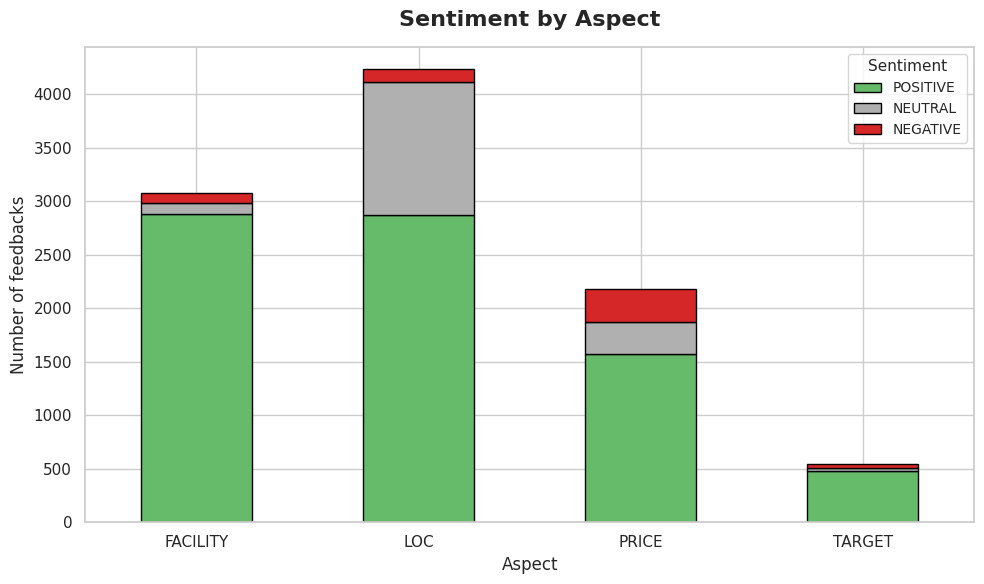

✅ Đã lưu biểu đồ 1: 1_Aspect_Sentiment_Distribution.png


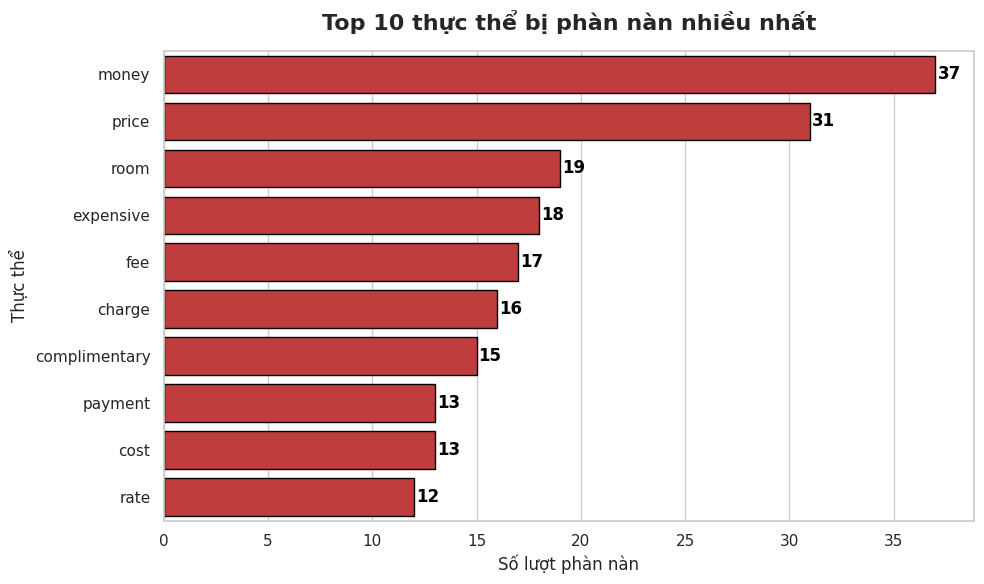

✅ Đã lưu biểu đồ 2: 2_Top_10_Negative_Objects.png


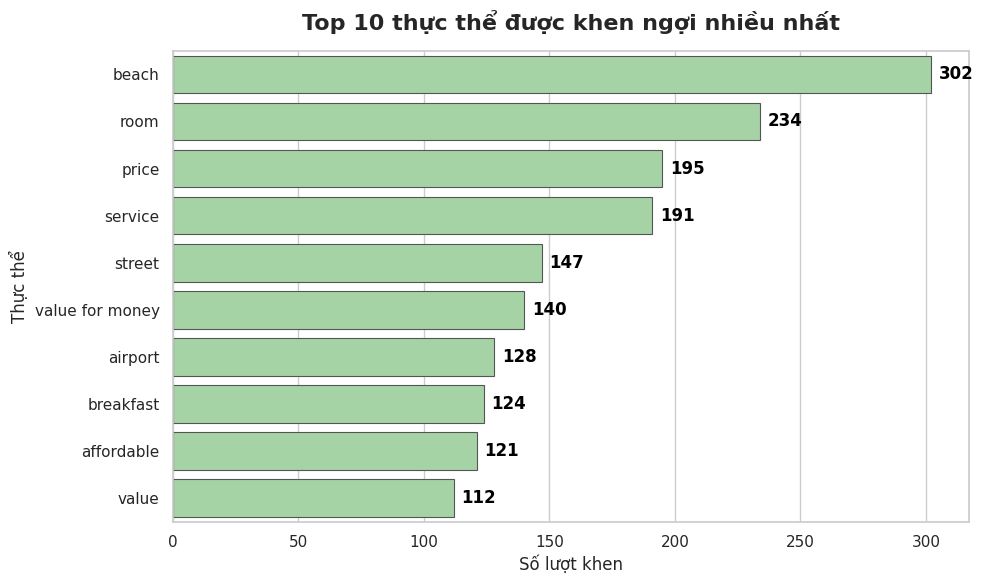

✅ Đã lưu biểu đồ 4: 4_Top_10_Positive_Objects.png


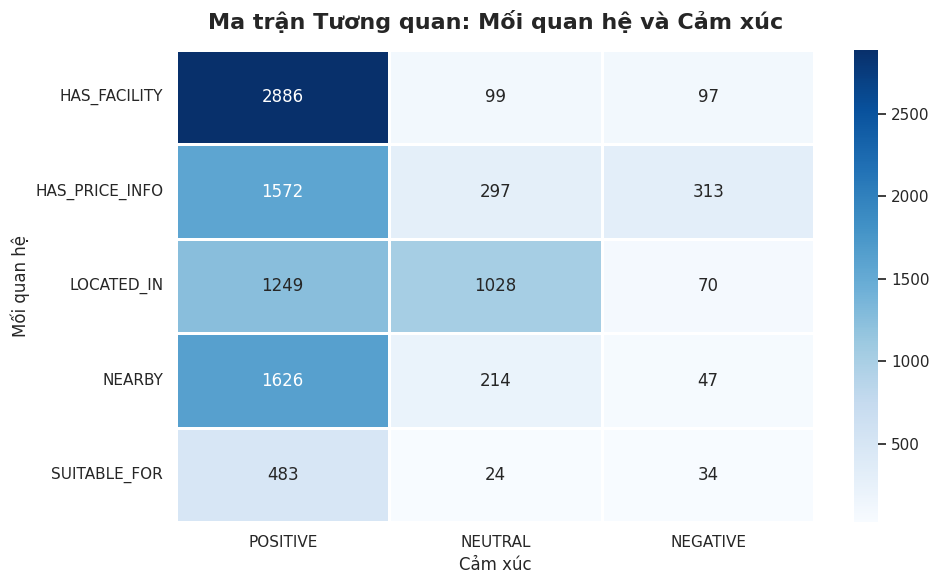

✅ Đã lưu biểu đồ 3: 3_Relation_Sentiment_Heatmap.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. ĐỌC DỮ LIỆU ĐÃ GÁN NHÃN
# ==========================================
file_path = '/content/drive/MyDrive/Thesis/Database_KG_Final.csv'
df = pd.read_csv(file_path)

# Bảng màu chuẩn mực cho luận văn
color_map = {
    'POSITIVE': '#66bb6a', # Xanh lá thảo mộc (đậm đà, rõ nét hơn)
    'NEUTRAL': '#b0b0b0',  # Xám tro (đủ chìm để làm nền, không bị lóa)
    'NEGATIVE': '#d62728'  # Đỏ san hô (cảnh báo rõ ràng nhưng không bị gắt)
}

# Đảm bảo các nhãn có mặt đầy đủ để vẽ không bị lỗi
sentiment_order = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
colors = [color_map[s] for s in sentiment_order if s in df['Predicted_Sentiment'].unique()]

sns.set_theme(style="whitegrid")

# ==========================================
# BIỂU ĐỒ 1: PHÂN BỐ CẢM XÚC THEO KHÍA CẠNH (ASPECT)
# ==========================================
plt.figure(figsize=(10, 6))

# Đếm số lượng Sentiment theo từng loại Object_Type (Aspect)
aspect_sentiment = pd.crosstab(df['Object_Type'], df['Predicted_Sentiment'])

# Sắp xếp lại thứ tự cột cho đúng Xanh -> Xám -> Đỏ
aspect_sentiment = aspect_sentiment.reindex(columns=sentiment_order, fill_value=0)

# Vẽ Stacked Bar Chart
ax = aspect_sentiment.plot(kind='bar', stacked=True, color=colors, figsize=(10, 6), edgecolor='black')

plt.title('Sentiment by Aspect', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Aspect', fontsize=12)
plt.ylabel('Number of feedbacks', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Sentiment', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig('1_Aspect_Sentiment_Distribution.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ 1: 1_Aspect_Sentiment_Distribution.png")

# ==========================================
# BIỂU ĐỒ 2: TOP 10 ĐỐI TƯỢNG BỊ CHÊ NHIỀU NHẤT (ALERT SYSTEM)
# ==========================================
plt.figure(figsize=(10, 6))

# Lọc ra những dòng bị gán nhãn NEGATIVE và lấy top 10 Object
df_negative = df[df['Predicted_Sentiment'] == 'NEGATIVE']
top_10_negative = df_negative['Object'].value_counts().head(10)

# Vẽ Horizontal Bar Chart (Biểu đồ cột ngang)
sns.barplot(x=top_10_negative.values, y=top_10_negative.index, color='#d62728', edgecolor='black')

plt.title('Top 10 thực thể bị phàn nàn nhiều nhất', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượt phàn nàn', fontsize=12)
plt.ylabel('Thực thể', fontsize=12)

# Điền số lên đuôi cột
for i, v in enumerate(top_10_negative.values):
    plt.text(v + 0.1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('2_Top_10_Negative_Objects.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ 2: 2_Top_10_Negative_Objects.png")
#============================================
# ==========================================
# BIỂU ĐỒ 3: TOP 10 ĐỐI TƯỢNG ĐƯỢC KHEN NHIỀU NHẤT (ĐIỂM SÁNG)
# ==========================================
plt.figure(figsize=(10, 6))

# Lọc ra những dòng được gán nhãn POSITIVE và lấy top 10 Object
df_positive = df[df['Predicted_Sentiment'] == 'POSITIVE']
top_10_positive = df_positive['Object'].value_counts().head(10)

# Vẽ Horizontal Bar Chart (Sử dụng màu xanh pastel và viền xám)
sns.barplot(x=top_10_positive.values, y=top_10_positive.index, color='#9edb9e', edgecolor='#555555', linewidth=0.8)

plt.title('Top 10 thực thể được khen ngợi nhiều nhất', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượt khen', fontsize=12)
plt.ylabel('Thực thể', fontsize=12)

# Điền số lên đuôi cột cho dễ nhìn
for i, v in enumerate(top_10_positive.values):
    plt.text(v + (top_10_positive.max() * 0.01), i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('4_Top_10_Positive_Objects.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ 4: 4_Top_10_Positive_Objects.png")

# ==========================================
# BIỂU ĐỒ 4: MA TRẬN QUAN HỆ & CẢM XÚC (HEATMAP)
# ==========================================
plt.figure(figsize=(10, 6))

# Tạo bảng tần suất giữa Relation và Sentiment
relation_sentiment = pd.crosstab(df['Relation'], df['Predicted_Sentiment'])
relation_sentiment = relation_sentiment.reindex(columns=sentiment_order, fill_value=0)

# Vẽ Heatmap
sns.heatmap(relation_sentiment, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='white')

plt.title('Ma trận Tương quan: Mối quan hệ và Cảm xúc', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Cảm xúc', fontsize=12)
plt.ylabel('Mối quan hệ', fontsize=12)

plt.tight_layout()
plt.savefig('3_Relation_Sentiment_Heatmap.png', dpi=300)
plt.show()
print("✅ Đã lưu biểu đồ 3: 3_Relation_Sentiment_Heatmap.png")

DeBERTa-v3

In [ ]:
!pip install transformers[sentencepiece] sentencepiece

In [ ]:
# 🚨 CHÚ Ý: Chạy riêng ô này trước trên Colab nếu chưa cài SentencePiece
# !pip install sentencepiece protobuf

import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# ==========================================
# 0. LÀM SẠCH DATA
# ==========================================
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

# Lọc bỏ các dòng không có nhãn (NaN)
df1 = df1.dropna(subset=['labels'])
df1['labels'] = df1['labels'].astype(int)

# 1. CHUẨN BỊ DATA INPUT (Cách nguyên thủy: Object - Sentence)
df1['Input_Text'] = df1['Object'].astype(str) + " - " + df1['Target_Sentence'].astype(str)

# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU
# ==========================================
min_class_count = df1['labels'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Mỗi nhãn bốc {n_test_per_class} mẫu vào tập Test để đảm bảo công bằng.")

df_test = df1.groupby('labels').sample(n=n_test_per_class, random_state=42)
df_train = df1.drop(df_test.index)

# ==========================================
# 1.5. BƠM MÁU CHO TẬP TRAIN (RANDOM OVERSAMPLING) - NEW 🔥
# ==========================================
# Thay vì ép trọng số (Weighted Loss), ta nhân bản các câu Negative/Neutral cho bằng Positive
print("💉 Đang tiến hành nhân bản dữ liệu nhãn thiểu số trong tập Train...")
max_size = df_train['labels'].value_counts().max()
lst_df = [df_train]

for class_index, group in df_train.groupby('labels'):
    if len(group) < max_size:
        # Bốc thêm mẫu ngẫu nhiên bù vào phần thiếu
        lst_df.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_train_balanced = pd.concat(lst_df)

# 🔥 DÒNG CỨU MẠNG: Xáo trộn (Shuffle) dữ liệu để AI không bị học vẹt nhãn cuối cùng
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train, y_train = df_train_balanced['Input_Text'].tolist(), df_train_balanced['labels'].tolist()

print(f"✅ Kích thước tập Train sau khi bơm máu: {len(X_train)} câu.")

# ==========================================
# 2. TOKENIZER & DATASET
# ==========================================
MODEL_NAME = 'microsoft/deberta-v3-base'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. TRAINER & HUẤN LUYỆN THUẦN
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,     # 🔥 LR thấp: Chống sốc cho DeBERTa
    warmup_ratio=0.1,       # 🔥 Warmup: Tăng tốc độ học từ từ
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print(f"🔥 Đang huấn luyện {MODEL_NAME} với tập Train đã Oversampling...")
trainer.train()

# ==========================================
# 4. ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("🏆 KẾT QUẢ DEBERTA-V3 (SAU KHI TỐI ƯU)")
print("="*50)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

📊 Mỗi nhãn bốc 31 mẫu vào tập Test để đảm bảo công bằng.
💉 Đang tiến hành nhân bản dữ liệu nhãn thiểu số trong tập Train...
✅ Kích thước tập Train sau khi bơm máu: 2070 câu.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      

🔥 Đang huấn luyện microsoft/deberta-v3-base với tập Train đã Oversampling...


Step,Training Loss
500,1.107887



🏆 KẾT QUẢ DEBERTA-V3 (SAU KHI TỐI ƯU)


              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00        31
     NEUTRAL       0.00      0.00      0.00        31
    POSITIVE       0.33      1.00      0.50        31

    accuracy                           0.33        93
   macro avg       0.11      0.33      0.17        93
weighted avg       0.11      0.33      0.17        93



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1. CHUẨN BỊ DATA
df1['Input_Text'] = df1['Object'].astype(str) + " - " + df1['Target_Sentence'].astype(str)
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
df1['labels'] = df1['Sentiment'].map(label_mapping)

# ==========================================
# 1.2. CHIẾN THUẬT BỐC TẬP TEST ĐỀU
# ==========================================
min_class_count = df1['labels'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Mỗi nhãn bốc {n_test_per_class} mẫu vào tập Test.")

df_test = df1.groupby('labels').sample(n=n_test_per_class, random_state=42)
df_train = df1.drop(df_test.index)

X_train, y_train = df_train['Input_Text'].tolist(), df_train['labels'].tolist()
X_test, y_test = df_test['Input_Text'].tolist(), df_test['labels'].tolist()

# ==========================================
# 2. TOKENIZER & DATASET
# ==========================================
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(X_train, y_train)
test_dataset = ReviewDataset(X_test, y_test)

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH (DÙNG TRAINER GỐC)
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

# KHÔNG CẦN CUSTOM LOSS NỮA, DÙNG TRAINER MẶC ĐỊNH CỦA HUGGINGFACE
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print("🔥 Đang huấn luyện RoBERTa (Chế độ mặc định - No Weighted Loss)...")
trainer.train()

# ==========================================
# 4. ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("🏆 KẾT QUẢ ROBERTA (KHÔNG TRỌNG SỐ)")
print("="*50)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

reverse_mapping = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
y_pred_text = [reverse_mapping[p] for p in y_pred]
y_true_text = [reverse_mapping[t] for t in y_test]

print(classification_report(y_true_text, y_pred_text))

📊 Mỗi nhãn bốc 31 mẫu vào tập Test.


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔥 Đang huấn luyện RoBERTa (Chế độ mặc định - No Weighted Loss)...


Step,Training Loss



🏆 KẾT QUẢ ROBERTA (KHÔNG TRỌNG SỐ)


              precision    recall  f1-score   support

    NEGATIVE       0.60      0.10      0.17        31
     NEUTRAL       0.40      0.45      0.42        31
    POSITIVE       0.58      1.00      0.74        31

    accuracy                           0.52        93
   macro avg       0.53      0.52      0.44        93
weighted avg       0.53      0.52      0.44        93



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. NHẬP DỮ LIỆU KẾT QUẢ ĐỂ VẼ BIỂU ĐỒ
# (Ông thay các số này bằng kết quả thực tế trên Colab của ông nhé)
# ==========================================
results = {
    'Mô hình': ['1. SVM (Baseline)', '1. SVM (Baseline)', '1. SVM (Baseline)', '1. SVM (Baseline)',
                '2. Bi-LSTM', '2. Bi-LSTM', '2. Bi-LSTM', '2. Bi-LSTM',
                '3. RoBERTa', '3. RoBERTa', '3. RoBERTa', '3. RoBERTa'],
    'Nhãn': ['NEGATIVE', 'NEUTRAL', 'POSITIVE', 'MACRO AVG'] * 3,
    'F1-Score': [
        # Điểm của SVM (Baseline)
        0.25, 0.26, 0.77, 0.43,

        # Điểm của Bi-LSTM (Ông tự nhập số thật ông chạy ra vào đây nha)
        0.45, 0.48, 0.80, 0.57,

        # Điểm RoBERTa (Chép từ ảnh ông vừa gửi tui)
        0.67, 0.53, 0.82, 0.67
    ]
}

df_results = pd.DataFrame(results)

# ==========================================
# 2. THIẾT LẬP GIAO DIỆN BIỂU ĐỒ (CHUẨN BÁO CÁO KHOA HỌC)
# ==========================================
plt.figure(figsize=(14, 7)) # Kích thước tỷ lệ vàng
sns.set_theme(style="whitegrid", font_scale=1.2) # Thêm lưới ngang cho dễ nhìn số

# Vẽ biểu đồ cột ghép
ax = sns.barplot(
    data=df_results,
    x='Nhãn',
    y='F1-Score',
    hue='Mô hình',
    palette='rocket' # Bảng màu 'rocket' nhìn rất ngầu và học thuật
)

# ==========================================
# 3. HIỂN THỊ CON SỐ TRÊN ĐỈNH TỪNG CỘT
# ==========================================
for p in ax.patches:
    # Bỏ qua mấy cột trống (nếu có)
    if pd.isna(p.get_height()):
        continue
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10), # Nâng số lên 10 pixel cho khỏi lẹm vào cột
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# ==========================================
# 4. TÚT TÁT NHAN SẮC VÀ XUẤT FILE ẢNH
# ==========================================
plt.title('ĐÁNH GIÁ VÀ SO SÁNH CHỈ SỐ F1-SCORE GIỮA CÁC KIẾN TRÚC MÔ HÌNH', pad=20, fontsize=16, fontweight='bold')
plt.ylim(0, 1.1) # Kéo đỉnh trục Y lên xíu cho đẹp
plt.ylabel('Điểm F1-Score', fontweight='bold', fontsize=14)
plt.xlabel('Phân loại Nhãn (Class) & Điểm Trung Bình', fontweight='bold', fontsize=14, labelpad=15)

# Đẩy cái ghi chú (Legend) ra ngoài để không che mất cột
plt.legend(title='Kiến trúc Mô hình', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

# LƯU FILE ẢNH CHẤT LƯỢNG CAO (300 DPI) ĐỂ BỎ VÀO WORD IN KHÔNG BỊ VỠ
plt.tight_layout()
plt.savefig('Bieu_Do_So_Sanh_Mo_Hinh.png', dpi=300)

print("📸 Đã lưu xong! Ông mở thư mục Colab bên trái, tải file 'Bieu_Do_So_Sanh_Mo_Hinh.png' về dán vào Word nhé!")
plt.show()

##LLM

In [ ]:
pip install pandas openpyxl groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 970.8 kB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
from groq import Groq
from sklearn.metrics import classification_report
import time

# ==========================================
# 1. CHUẨN BỊ DATA & BỐC TẬP TEST ĐỀU
# ==========================================
file_path = '/content/drive/MyDrive/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

# Tìm nhãn có ít mẫu nhất
min_class_count = df['Sentiment'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

print(f"📊 Bốc đều {n_test_per_class} mẫu cho mỗi nhãn vào tập Test để LLM chấm điểm...\n")

# Bốc mẫu Test cân bằng
df_test = df.groupby('Sentiment').sample(n=n_test_per_class, random_state=42)

# Tạo cột Input_Text
df_test['Input_Text'] = df_test['Object'].astype(str) + " - " + df_test['Target_Sentence'].astype(str)

X_test = df_test['Input_Text'].tolist()
# Lấy thẳng danh sách nhãn bằng CHỮ để lát so sánh với LLM luôn, khỏi cần map ra số
y_true_llm = df_test['Sentiment'].tolist()

# ==========================================
# 2. KHAI BÁO API KEY VÀ HÀM LLM
# ==========================================
os.environ["GROQ_API_KEY"] = ""
client = Groq()

def predict_sentiment_llm(aspect, sentence):
    prompt = f"""You are an Expert Linguist specializing in Aspect-Based Sentiment Analysis (ABSA) for hotel reviews.
Analyze the sentiment expressed ONLY toward the specific Aspect: "{aspect}" within this Sentence: "{sentence}".

Rules:
- If complaining, negative, or broken -> NEGATIVE
- If praising, satisfied, or good -> POSITIVE
- If purely stating a fact (e.g., "The room is 20sqm", "No window") without emotional complaint -> NEUTRAL

Output ONLY ONE WORD: POSITIVE, NEGATIVE, or NEUTRAL."""

    try:
        completion = client.chat.completions.create(
            # 🔥 ĐÂY LÀ CHÌA KHÓA: Phải xài đúng tên Model của Groq
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
            max_tokens=5
        )
        result = completion.choices[0].message.content.strip().upper()

        if "POSITIVE" in result: return "POSITIVE"
        if "NEGATIVE" in result: return "NEGATIVE"
        if "NEUTRAL" in result: return "NEUTRAL"

        return "NEUTRAL" # Nếu nó trả lời lan man

    except Exception as e:
        # 🔥 Gỡ bẫy: In thẳng lỗi ra màn hình để biết đường sửa
        print(f"\n🚨 CÓ LỖI API RỒI ÔNG ƠI: {e}")
        return "ERROR"

# ==========================================
# 3. CHẠY DỰ ĐOÁN TỪNG CÂU
# ==========================================
y_pred_llm = []

print(f"🚀 LLM đang xử lý {len(X_test)} câu bằng kỹ thuật Chain-of-Thought...")

for i, combined_text in enumerate(X_test):
    parts = combined_text.split(" - ", 1)
    aspect = parts[0]
    sentence = parts[1] if len(parts) > 1 else ""

    pred = predict_sentiment_llm(aspect, sentence)
    y_pred_llm.append(pred)

    if (i+1) % 10 == 0:
        print(f"✅ Đã phân tích xong: {i+1}/{len(X_test)} câu...")

    # Ngủ 1 giây để né Rate Limit của Groq (Tăng từ 0.5 lên 1.0 cho an toàn)
    time.sleep(1.0)

# ==========================================
# 4. BÁO CÁO KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM LLM (FEW-SHOT + CHAIN-OF-THOUGHT)")
print("="*50)

print(classification_report(y_true_llm, y_pred_llm))

📊 Bốc đều 31 mẫu cho mỗi nhãn vào tập Test để LLM chấm điểm...

🚀 LLM đang xử lý 93 câu bằng kỹ thuật Chain-of-Thought...
✅ Đã phân tích xong: 10/93 câu...
✅ Đã phân tích xong: 20/93 câu...
✅ Đã phân tích xong: 30/93 câu...
✅ Đã phân tích xong: 40/93 câu...
✅ Đã phân tích xong: 50/93 câu...
✅ Đã phân tích xong: 60/93 câu...
✅ Đã phân tích xong: 70/93 câu...
✅ Đã phân tích xong: 80/93 câu...
✅ Đã phân tích xong: 90/93 câu...

🏆 BẢNG ĐIỂM LLM (FEW-SHOT + CHAIN-OF-THOUGHT)
              precision    recall  f1-score   support

    NEGATIVE       0.81      0.81      0.81        31
     NEUTRAL       0.56      0.48      0.52        31
    POSITIVE       0.69      0.77      0.73        31

    accuracy                           0.69        93
   macro avg       0.68      0.69      0.68        93
weighted avg       0.68      0.69      0.68        93



In [ ]:
import os
from groq import Groq

os.environ["GROQ_API_KEY"] = ""
client = Groq()


try:
    # Gọi API lấy danh sách models
    models = client.models.list()

    print("="*50)
    print("✅ CÁC MODEL ĐANG HOẠT ĐỘNG TRÊN GROQ (Copy tên dán vào code):")
    print("="*50)

    # In ra ID của từng model
    for idx, m in enumerate(models.data):
        print(f"{idx + 1}. {m.id}")

except Exception as e:
    print(f"🚨 Lỗi không lấy được danh sách: {e}")

⏳ Đang kết nối tới máy chủ Groq để lấy danh sách Model...

✅ CÁC MODEL ĐANG HOẠT ĐỘNG TRÊN GROQ (Copy tên dán vào code):
1. meta-llama/llama-4-scout-17b-16e-instruct
2. llama-3.1-8b-instant
3. llama-3.3-70b-versatile
4. meta-llama/llama-prompt-guard-2-86m
5. groq/compound
6. groq/compound-mini
7. whisper-large-v3
8. allam-2-7b
9. canopylabs/orpheus-arabic-saudi
10. whisper-large-v3-turbo
11. meta-llama/llama-prompt-guard-2-22m
12. canopylabs/orpheus-v1-english
13. openai/gpt-oss-20b
14. openai/gpt-oss-120b
15. openai/gpt-oss-safeguard-20b
16. qwen/qwen3-32b


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
from groq import Groq
from sklearn.metrics import classification_report
import time

# ==========================================
# 1. CHUẨN BỊ DATA & BỐC TẬP TEST ĐỀU
# ==========================================
file_path = '/content/drive/MyDrive/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)
df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

min_class_count = df['Sentiment'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

df_test = df.groupby('Sentiment').sample(n=n_test_per_class, random_state=42)
df_test['Input_Text'] = df_test['Object'].astype(str) + " - " + df_test['Target_Sentence'].astype(str)

X_test = df_test['Input_Text'].tolist()
y_true_llm = df_test['Sentiment'].tolist()

# ==========================================
# 2. KHAI BÁO API KEY VÀ HÀM LLM
# ==========================================
os.environ["GROQ_API_KEY"] = ""
client = Groq()

def predict_sentiment_llm(aspect, sentence):
    prompt = f"""Analyze the sentiment expressed ONLY toward the specific Aspect: "{aspect}" within this Sentence: "{sentence}".

Rules:
- NEGATIVE: Expresses complaint, dissatisfaction, or something is broken/bad.
- POSITIVE: Expresses praise, satisfaction, or something is good.
- NEUTRAL: Purely factual statement, observation, or lack of clear emotion.

Output ONLY ONE WORD: POSITIVE, NEGATIVE, or NEUTRAL."""

    try:
        completion = client.chat.completions.create(
            model="qwen/qwen3-32b", #
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
            max_tokens=5
        )
        result = completion.choices[0].message.content.strip().upper()

        if "POSITIVE" in result: return "POSITIVE"
        if "NEGATIVE" in result: return "NEGATIVE"
        if "NEUTRAL" in result: return "NEUTRAL"

        return "NEUTRAL"

    except Exception as e:
        print(f"\n🚨 Lỗi: {e}")
        return "NEUTRAL"

# ==========================================
# 3. CHẠY DỰ ĐOÁN
# ==========================================
y_pred_llm = []

for i, combined_text in enumerate(X_test):
    parts = combined_text.split(" - ", 1)
    aspect = parts[0]
    sentence = parts[1] if len(parts) > 1 else ""

    pred = predict_sentiment_llm(aspect, sentence)
    y_pred_llm.append(pred)

    if (i+1) % 10 == 0:
        print(f"✅ Đã xong: {i+1}/{len(X_test)} câu...")
    time.sleep(1.0)

# ==========================================
# 4. BÁO CÁO
# ==========================================
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM LLM (Llama-3.3-70B)")
print("="*50)

print(classification_report(y_true_llm, y_pred_llm))

Mounted at /content/drive
✅ Đã xong: 10/93 câu...
✅ Đã xong: 20/93 câu...
✅ Đã xong: 30/93 câu...
✅ Đã xong: 40/93 câu...
✅ Đã xong: 50/93 câu...
✅ Đã xong: 60/93 câu...
✅ Đã xong: 70/93 câu...
✅ Đã xong: 80/93 câu...
✅ Đã xong: 90/93 câu...

🏆 BẢNG ĐIỂM LLM (Llama-3.3-70B)
              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00        31
     NEUTRAL       0.33      1.00      0.50        31
    POSITIVE       0.00      0.00      0.00        31

    accuracy                           0.33        93
   macro avg       0.11      0.33      0.17        93
weighted avg       0.11      0.33      0.17        93



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Gemini

In [ ]:
!pip install -U google-generativeai

In [ ]:
import os
import pandas as pd
import google.generativeai as genai
from sklearn.metrics import classification_report
import time

# ==========================================
# 1. CHUẨN BỊ DATA & BỐC TẬP TEST ĐỀU
# ==========================================
file_path = '/content/drive/MyDrive/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)
df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

min_class_count = df['Sentiment'].value_counts().min()
n_test_per_class = int(min_class_count * 0.4)
if n_test_per_class < 5: n_test_per_class = 5

df_test = df.groupby('Sentiment').sample(n=n_test_per_class, random_state=42)
df_test['Input_Text'] = df_test['Object'].astype(str) + " - " + df_test['Target_Sentence'].astype(str)

X_test = df_test['Input_Text'].tolist()
y_true_llm = df_test['Sentiment'].tolist()

# ==========================================
# 2. CẤU HÌNH API GEMINI
# ==========================================
GOOGLE_API_KEY = ""
genai.configure(api_key=GOOGLE_API_KEY)

# Sử dụng mô hình Gemini 1.5 Flash (Xử lý text cực nhanh và chính xác)
model_gemini = genai.GenerativeModel('models/gemini-flash-latest')

def predict_sentiment_gemini(aspect, sentence):
    prompt = f"""You are an Expert in Aspect-Based Sentiment Analysis (ABSA).
Analyze the sentiment expressed ONLY toward this specific Aspect: "{aspect}" within the following Sentence: "{sentence}".

Rules for classification:
1. NEGATIVE: The sentence expresses a complaint, dissatisfaction, or negative emotional reaction toward the aspect (e.g., "too small", "terrible", "broken").
2. POSITIVE: The sentence expresses praise, satisfaction, or positive emotional reaction toward the aspect (e.g., "great", "friendly", "clean").
3. NEUTRAL: The sentence is purely a factual observation, an objective statement without clear emotional charge, or states a feature without complaining (e.g., "The room has no window", "Check-in is at 2PM").

Respond with EXACTLY ONE WORD from these three options: POSITIVE, NEGATIVE, or NEUTRAL."""

    try:
        response = model_gemini.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(
                temperature=0.0,
            )
        )

        result = response.text.strip().upper()

        if "POSITIVE" in result: return "POSITIVE"
        if "NEGATIVE" in result: return "NEGATIVE"
        if "NEUTRAL" in result: return "NEUTRAL"

        return "NEUTRAL"

    except Exception as e:
        print(f"\n🚨 Lỗi Gemini API: {e}")
        return "NEUTRAL"


y_pred_llm = []
print(f"🚀 Gemini 1.5 Flash đang xử lý {len(X_test)} câu...")

for i, combined_text in enumerate(X_test):
    parts = combined_text.split(" - ", 1)
    aspect = parts[0]
    sentence = parts[1] if len(parts) > 1 else ""

    pred = predict_sentiment_gemini(aspect, sentence)
    y_pred_llm.append(pred)

    if (i+1) % 10 == 0:
        print(f"✅ Đã phân tích xong: {i+1}/{len(X_test)} câu...")

    time.sleep(4.0)

# ==========================================
# 4. BÁO CÁO KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM LLM (Google Gemini 1.5 Flash)")
print("="*50)

print(classification_report(y_true_llm, y_pred_llm))

🚀 Gemini 1.5 Flash đang xử lý 93 câu...
✅ Đã phân tích xong: 10/93 câu...



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3-flash
Please retry in 55.222455053s.



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3-flash
Please retry in 51.021314764s.



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3-flash
Please retry in 49.739503046s.
✅ Đã phân tích xong: 20/93 câu...



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 45.550198383s.


...


🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 59.470760825s.



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 55.243456032s.
✅ Đã phân tích xong: 90/93 câu...



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 51.035601217s.



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 46.839507377s.



🚨 Lỗi Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 42.638564994s.

🏆 BẢNG ĐIỂM LLM (Google Gemini 1.5 Flash)
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.42      0.59        31
     NEUTRAL       0.39      1.00      0.56        31
    POSITIVE       0.00      0.00      0.00        31

    accuracy                           0.47        93
   macro avg       0.46      0.47      0.38        93
weighted avg       0.46      0.47      0.38        93



#GPT

In [ ]:
!pip install openai

In [ ]:
import os
import pandas as pd
from openai import OpenAI
from sklearn.metrics import classification_report
import time


file_path = '/content/drive/MyDrive/Thesis/Manual_sentiment.xlsx'
df = pd.read_excel(file_path)

# Lọc bỏ các dòng trống
df = df.dropna(subset=['Target_Sentence', 'Object', 'Sentiment'])

min_class_count = df['Sentiment'].value_counts().min()

print(f"📊 Đang bốc đều {min_class_count} câu mỗi nhãn (Tổng: {min_class_count * 3} câu) để GPT thi thố công bằng...\n")

df_balanced = df.groupby('Sentiment').sample(n=min_class_count, random_state=42)
df_balanced['Input_Text'] = df_balanced['Object'].astype(str) + " - " + df_balanced['Target_Sentence'].astype(str)

# Vác đi thi
X_test = df_balanced['Input_Text'].tolist()
y_true_llm = df_balanced['Sentiment'].tolist()

# ==========================================
# 2. CẤU HÌNH API OPENAI
# ==========================================
os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()

def predict_sentiment_gpt(aspect, sentence):
    prompt = f"""You are a professional Data Annotator specializing in Aspect-Based Sentiment Analysis (ABSA) for the hospitality industry. Your goal is to determine the sentiment expressed toward a specific "Aspect" within a given sentence.

**Classification Logic (Strict):**
1. **POSITIVE**: Subjective praise, expressions of satisfaction, or highlighting high quality (e.g., "The staff was helpful", "Amazing view", "Clean room").
2. **NEGATIVE**: Complaints, disappointments, or reporting issues and failures (e.g., "Noisy room", "The price is too high", "The WiFi didn't work").
3. **NEUTRAL**: Purely factual or descriptive statements about facilities/services without emotional adjectives. Mentioning the existence of an item or its location is NEUTRAL (e.g., "The room has a bathtub", "The hotel is near the airport").

**Contextual Examples (Few-shot):**
- Sentence: "The Lumiere Hotel is located near the airport." | Aspect: "Location" -> NEUTRAL
- Sentence: "The room is spacious and very clean." | Aspect: "Room" -> POSITIVE
- Sentence: "The bathroom was small and there was no hot water." | Aspect: "Bathroom" -> NEGATIVE
- Sentence: "Our stay included a free breakfast buffet." | Aspect: "Breakfast" -> NEUTRAL

**Task:**
Analyze the sentiment of this specific Aspect: "{aspect}"
In this Sentence: "{sentence}"

**Output:**
Respond with EXACTLY ONE WORD: [POSITIVE, NEGATIVE, NEUTRAL]."""

    try:
        completion = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a precise ABSA classifier. You only output exactly one word."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.0,
            max_tokens=5
        )
        result = completion.choices[0].message.content.strip().upper()

        # Bắt từ khóa
        if "POSITIVE" in result: return "POSITIVE"
        if "NEGATIVE" in result: return "NEGATIVE"
        if "NEUTRAL" in result: return "NEUTRAL"

        return "NEUTRAL" # Fallback an toàn

    except Exception as e:
        print(f"\n🚨 Lỗi OpenAI API: {e}")
        return "NEUTRAL"

# ==========================================
# 3. CHẠY DỰ ĐOÁN
# ==========================================
y_pred_llm = []
print(f"🚀 GPT-4o-mini đang xử lý {len(X_test)} câu...")

for i, combined_text in enumerate(X_test):
    parts = combined_text.split(" - ", 1)
    aspect = parts[0]
    sentence = parts[1] if len(parts) > 1 else ""

    pred = predict_sentiment_gpt(aspect, sentence)
    y_pred_llm.append(pred)

    if (i+1) % 10 == 0:
        print(f"✅ Đã phân tích xong: {i+1}/{len(X_test)} câu...")

    time.sleep(0.5)

# ==========================================
# 4. BÁO CÁO KẾT QUẢ
# ==========================================
print("\n" + "="*50)
print("🏆 BẢNG ĐIỂM LLM (OpenAI GPT-4o-mini)")
print("="*50)

print(classification_report(y_true_llm, y_pred_llm))

📊 Đang bốc đều 79 câu mỗi nhãn (Tổng: 237 câu) để GPT thi thố công bằng...

🚀 GPT-4o-mini đang xử lý 237 câu...
✅ Đã phân tích xong: 10/237 câu...
✅ Đã phân tích xong: 20/237 câu...
✅ Đã phân tích xong: 30/237 câu...
✅ Đã phân tích xong: 40/237 câu...
✅ Đã phân tích xong: 50/237 câu...
✅ Đã phân tích xong: 60/237 câu...
✅ Đã phân tích xong: 70/237 câu...
✅ Đã phân tích xong: 80/237 câu...
✅ Đã phân tích xong: 90/237 câu...
✅ Đã phân tích xong: 100/237 câu...
✅ Đã phân tích xong: 110/237 câu...
✅ Đã phân tích xong: 120/237 câu...
✅ Đã phân tích xong: 130/237 câu...
✅ Đã phân tích xong: 140/237 câu...
✅ Đã phân tích xong: 150/237 câu...
✅ Đã phân tích xong: 160/237 câu...
✅ Đã phân tích xong: 170/237 câu...
✅ Đã phân tích xong: 180/237 câu...
✅ Đã phân tích xong: 190/237 câu...
✅ Đã phân tích xong: 200/237 câu...
✅ Đã phân tích xong: 210/237 câu...
✅ Đã phân tích xong: 220/237 câu...
✅ Đã phân tích xong: 230/237 câu...

🏆 BẢNG ĐIỂM LLM (OpenAI GPT-4o-mini)
              precision    reca

✅ Đã vẽ xong và lưu file ảnh 'Model_Comparison_Chart.png' với chất lượng 300 DPI.


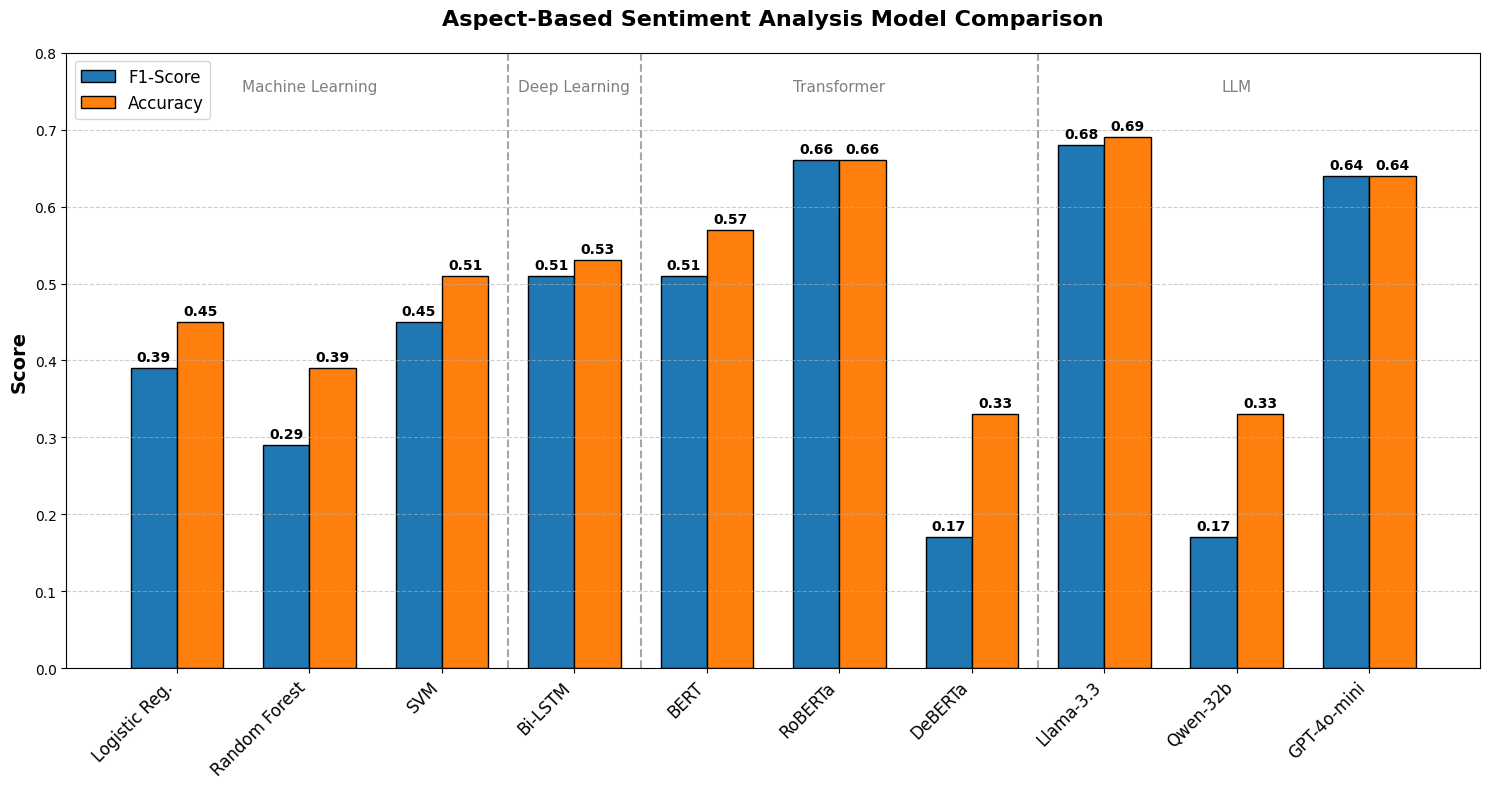

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. KHAI BÁO DỮ LIỆU TỪ BẢNG CỦA ÔNG
# ==========================================
# Tên các mô hình
models = [
    'Logistic Reg.', 'Random Forest', 'SVM',        # ML
    'Bi-LSTM',                                      # DL
    'BERT', 'RoBERTa', 'DeBERTa',                   # Transformer
    'Llama-3.3', 'Qwen-32b', 'GPT-4o-mini'          # LLM
]

# Chỉ số F1-Score và Accuracy tương ứng
f1_scores = [0.39, 0.29, 0.45, 0.51, 0.51, 0.66, 0.17, 0.68, 0.17, 0.64]
accuracies = [0.45, 0.39, 0.51, 0.53, 0.57, 0.66, 0.33, 0.69, 0.33, 0.64]

# ==========================================
# 2. CẤU HÌNH VẼ BIỂU ĐỒ (STYLE BÁO CÁO KHOA HỌC)
# ==========================================
x = np.arange(len(models))  # Vị trí các nhãn trên trục x
width = 0.35  # Độ rộng của các cột

# Tạo khung vẽ (Kích thước lớn để dễ nhìn)
fig, ax = plt.subplots(figsize=(15, 8))

# Vẽ 2 cột ghép sát nhau (Màu sắc nhã nhặn, chuyên nghiệp)
rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='#1f77b4', edgecolor='black')
rects2 = ax.bar(x + width/2, accuracies, width, label='Accuracy', color='#ff7f0e', edgecolor='black')

# ==========================================
# 3. TRANG TRÍ VÀ THÊM CHI TIẾT
# ==========================================
# Thêm tiêu đề và nhãn trục
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Aspect-Based Sentiment Analysis Model Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right", fontsize=12)
ax.set_ylim(0, 0.8) # Chỉnh trục Y tối đa là 0.8 để biểu đồ có khoảng không đẹp mắt

# Thêm vạch phân chia các nhóm mô hình cho dễ nhìn (Tùy chọn)
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.7)
ax.text(1, 0.75, 'Machine Learning', fontsize=11, color='gray', ha='center')

ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.7)
ax.text(3, 0.75, 'Deep Learning', fontsize=11, color='gray', ha='center')

ax.axvline(x=6.5, color='gray', linestyle='--', alpha=0.7)
ax.text(5, 0.75, 'Transformer', fontsize=11, color='gray', ha='center')

ax.text(8, 0.75, 'LLM', fontsize=11, color='gray', ha='center')

# Hiển thị chú thích (Legend)
ax.legend(fontsize=12, loc='upper left')

# ==========================================
# 4. HÀM TỰ ĐỘNG GHI SỐ LÊN ĐẦU CỘT
# ==========================================
def autolabel(rects):
    """Gắn label giá trị lên từng cột."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Dịch lên 3 points
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Lưới kẻ ngang mờ để dễ dóng số
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Tinh chỉnh layout gọn gàng
fig.tight_layout()

# ==========================================
# 5. XUẤT RA FILE ẢNH (300 DPI CHUẨN IN ẤN)
# ==========================================
plt.savefig('Model_Comparison_Chart.png', dpi=300, bbox_inches='tight')
print("✅ Đã vẽ xong và lưu file ảnh 'Model_Comparison_Chart.png' với chất lượng 300 DPI.")

# Hiển thị luôn trên Colab
plt.show()